<a href="https://colab.research.google.com/github/Karthikshetty003/Miniproject-01/blob/main/storessalesforecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv(
    "stores_sales_forecasting.csv",
    encoding='latin1'
)

print("Dataset Loaded Successfully\n")

Dataset Loaded Successfully



In [ ]:
df.columns = df.columns.str.strip()

# Display column names
print("Dataset Columns:\n")
print(df.columns)

Dataset Columns:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Sort data by date
df = df.sort_values('Order Date')

print("\nDataset Cleaned Successfully\n")


Dataset Cleaned Successfully



In [ ]:
df = df[df['Sales'] < df['Sales'].quantile(0.95)]

print("Outliers Removed Successfully\n")

Outliers Removed Successfully



In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
label_encoder = LabelEncoder()
df['Category'] = label_encoder.fit_transform(df['Category'])

df['Region'] = label_encoder.fit_transform(df['Region'])

df['Ship Mode'] = label_encoder.fit_transform(df['Ship Mode'])

In [ ]:
X = df[[
    'Year',
    'Month',
    'Day',
    'Quantity',
    'Discount',
    'Profit',
    'Category',
    'Region',
    'Ship Mode'
]]
y = df['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Regressor Model Trained Successfully\n")

Random Forest Regressor Model Trained Successfully



In [ ]:

y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

accuracy = r2_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========\n")

print("MAE  :", round(mae, 2))

print("MSE  :", round(mse, 2))

print("RMSE :", round(rmse, 2))

print("R2 Score :", round(accuracy, 2))

print("Accuracy :", round(accuracy * 100, 2), "%")


========== MODEL EVALUATION ==========

MAE  : 92.13
MSE  : 22211.59
RMSE : 149.04
R2 Score : 0.7
Accuracy : 70.22 %


In [ ]:
results = pd.DataFrame({
    'Actual Sales': y_test.values[:10],
    'Predicted Sales': y_pred[:10]
})

print("\n========== SAMPLE PREDICTIONS ==========\n")

print(results)


========== SAMPLE PREDICTIONS ==========

   Actual Sales  Predicted Sales
0       756.800       419.646920
1       796.425       716.642390
2        38.976        65.738970
3       170.352       268.155388
4        30.880        23.446640
5        35.560        55.417700
6        24.270        27.394900
7       435.260       392.850700
8       177.225       264.298707
9       332.940       327.221500


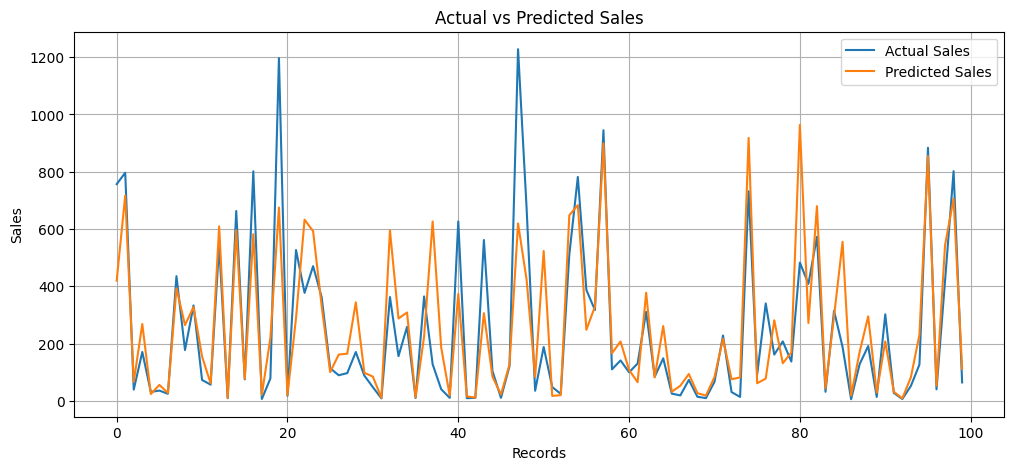

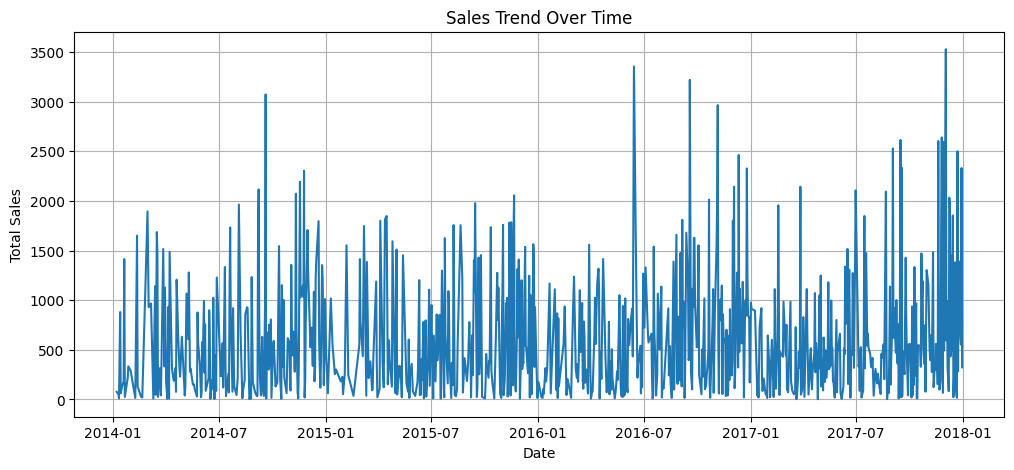

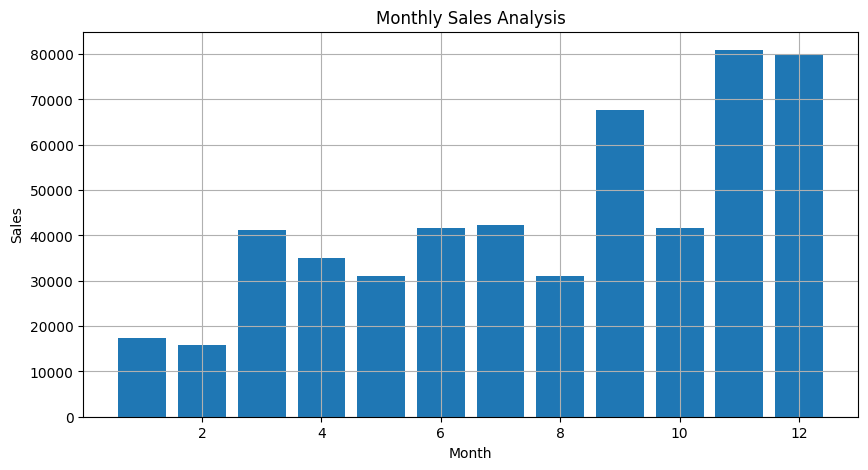

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(y_pred[:100], label='Predicted Sales')

plt.title("Actual vs Predicted Sales")

plt.xlabel("Records")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()


daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()





monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Analysis")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

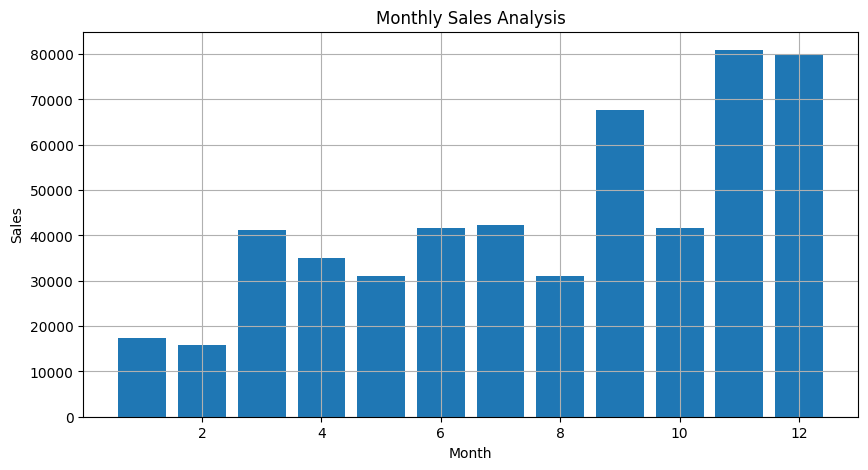

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Analysis")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

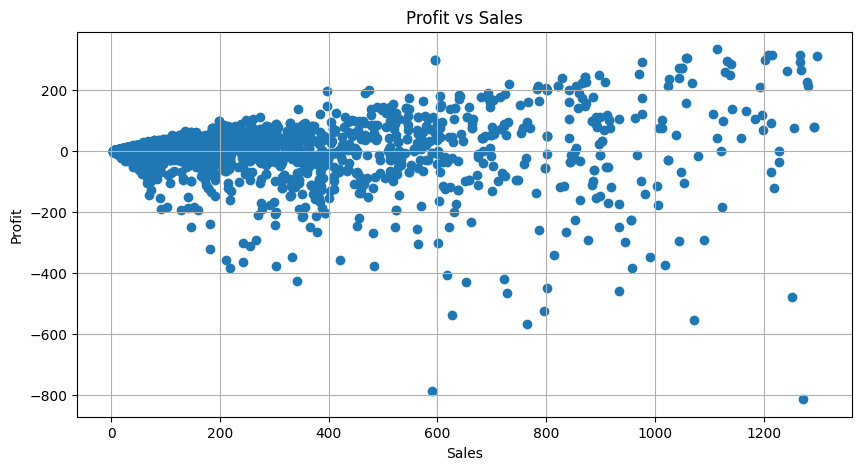

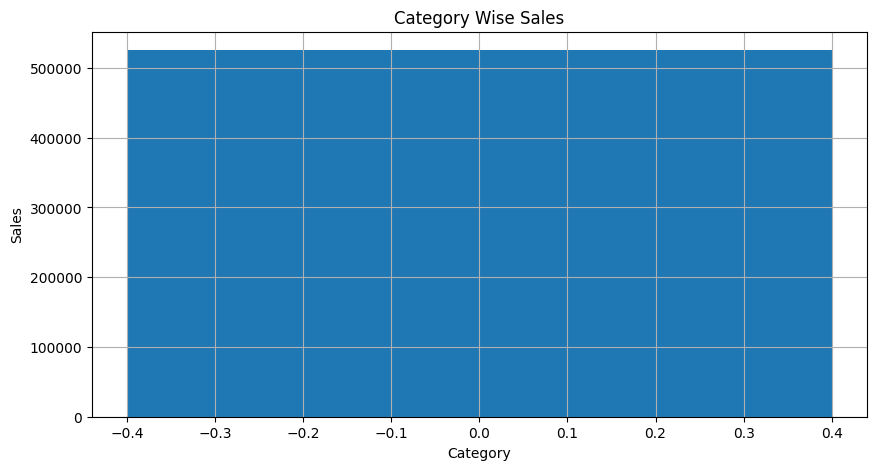

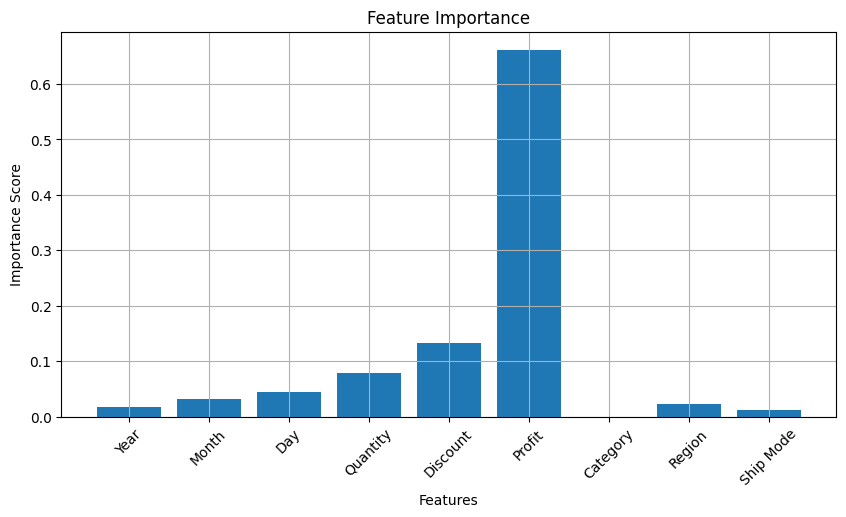

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(df['Sales'], df['Profit'])

plt.title("Profit vs Sales")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.grid(True)

plt.show()


category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10,5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Category Wise Sales")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.grid(True)

plt.show()


importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(10,5))

plt.bar(feature_names, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()
